# Deep Learning

- James, 2023, Chatper 10
- 豆包: <https://www.doubao.com/thread/waa27030197d6c932>

## 简介

## CNN 卷积神经网络 

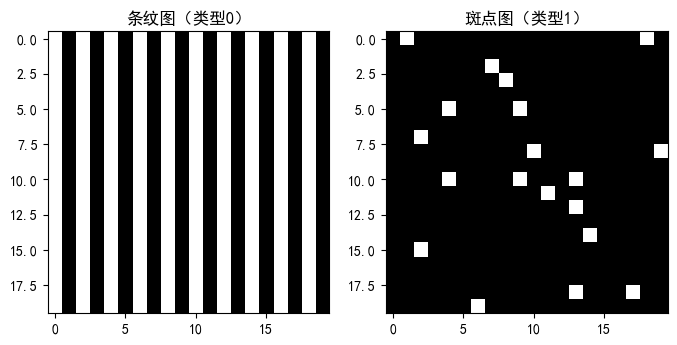

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 支持中文字符显示
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体（如系统无此字体请改为可用中文字体）
mpl.rcParams['axes.unicode_minus'] = False   # 解决负号 '-' 显示为方块的问题

import warnings
warnings.filterwarnings('ignore')


# 1. 生成训练数据：100张条纹图和100张斑点图（20x20像素）
def create_data():
    # 生成条纹图（类型0）：垂直黑白条纹
    stripe_imgs = []
    for _ in range(100):
        img = np.zeros((20, 20))  # 黑色背景
        # 每隔2列画白色条纹
        for col in range(0, 20, 2):
            img[:, col] = 255  # 白色条纹
        stripe_imgs.append(img)
    
    # 生成斑点图（类型1）：随机彩色斑点（这里简化为白色斑点）
    spot_imgs = []
    for _ in range(100):
        img = np.zeros((20, 20))  # 黑色背景
        # 随机画20个白色斑点
        for _ in range(20):
            x = np.random.randint(0, 20)
            y = np.random.randint(0, 20)
            img[x, y] = 255  # 白色斑点
        spot_imgs.append(img)
    
    # 合并数据并打标签：0=条纹，1=斑点
    X = np.array(stripe_imgs + spot_imgs).reshape(-1, 20, 20, 1)  # 加一个通道维度（黑白图）
    y = np.array([0]*100 + [1]*100)  # 标签
    return X / 255.0, y  # 归一化到0-1之间并返回标签

# 生成数据并展示示例
X, y = create_data()
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(X[0].reshape(20,20), cmap='gray')
plt.title("条纹图（类型0）")
plt.subplot(122)
plt.imshow(X[100].reshape(20,20), cmap='gray')
plt.title("斑点图（类型1）")
plt.show()


帮我呈现训练数据的分布情况，并显示其中一个图形对应的数据情况。

为下面的代码配一个单独的 Markdown 格式的文本框，解释如下代码的目的，思路和要展示的结果。

# 训练数据分布与单张图像详情说明

目的

- 直观展示生成的两类训练样本（条纹 vs 斑点）的整体分布与典型样例，并打印选中一张图像的像素矩阵与非零像素位置，便于理解数据特征与后续建模效果。

思路（代码对应步骤）

1. 标签分布：统计并绘制每类样本数量的柱状图（labels, counts），用于确认类别均衡性。  
2. 平均亮度分布：计算每张图像的平均亮度 means，并按类别绘制直方图，观察两类在亮度统计量上的差异。  
3. 示例图像：上排显示若干条纹样例，下排显示若干斑点样例（在标题中标注样本索引和标签），方便人工快速比对特征形态。  
4. 详细查看：选择 index_detail 所指的样本，单独显示其图像并打印对应的二维像素矩阵（归一化后的 0~1 值），同时列出非零像素的位置示例，便于检查噪声、斑点分布或条纹规律。

要展示的结果（如何解读）

- 柱状图应显示两类样本各 100 个，确认数据均衡。  
- 平均亮度直方图可揭示条纹（高占比白色列）与斑点（稀疏白点）在均值上的分布差异。  
- 示例图能直接看到条纹的规则模式与斑点的随机分布，有助于理解模型学习的目标特征。  
- 打印的像素矩阵和非零像素位置便于定位斑点坐标或验证生成逻辑是否符合预期。

备注 / 可调整项
- index_detail：修改为任意 idx_stripes 或 idx_spots 的索引，可查看不同样本详情。  
- 可增加更多统计指标（如方差、非零像素计数）以获得更丰富的数据描述。

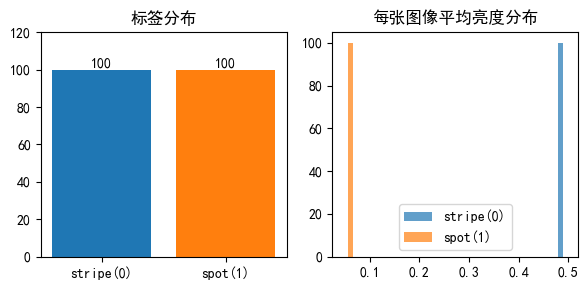

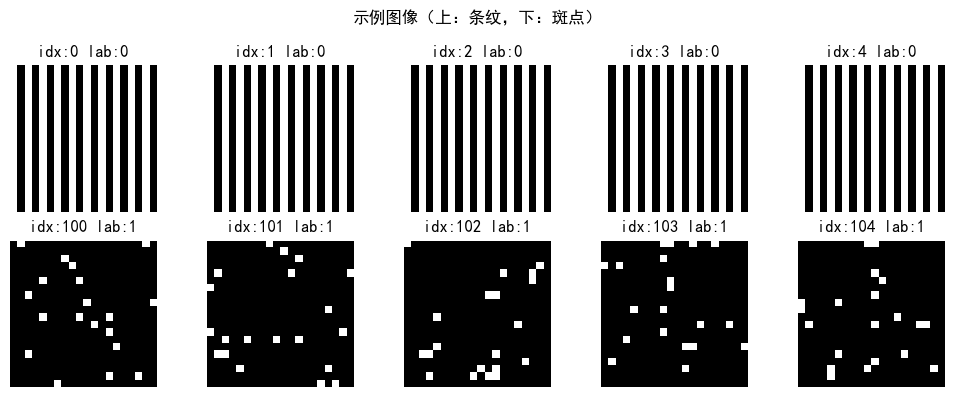

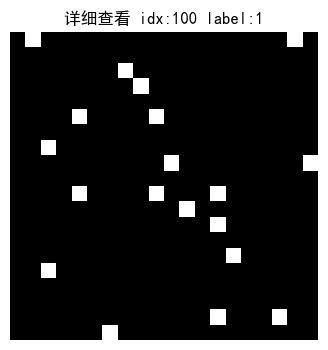

像素矩阵（shape=(20, 20)）：
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0

In [6]:
# 展示训练数据分布并显示某一张图像的数值信息
# 依赖已有变量：X, y, np, plt

# 1) 标签分布
counts = np.bincount(y)
labels = ['stripe(0)', 'spot(1)']

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.bar(labels, counts, color=['C0','C1'])
plt.title("标签分布")
for i, c in enumerate(counts):
    plt.text(i, c+1, str(c), ha='center')
plt.ylim(0, counts.max()*1.2)

# 2) 每张图像的平均亮度分布（按类别）
means = X.mean(axis=(1,2,3))
plt.subplot(1,2,2)
plt.hist([means[y==0], means[y==1]], bins=20, label=labels, color=['C0','C1'], alpha=0.7)
plt.title("每张图像平均亮度分布")
plt.legend()
plt.tight_layout()
plt.show()

# 3) 展示若干示例图（上排为条纹，下排为斑点），并在标题中标注索引
idx_stripes = np.where(y == 0)[0][:5]
idx_spots = np.where(y == 1)[0][:5]

plt.figure(figsize=(10,4))
for i, idx in enumerate(idx_stripes):
    plt.subplot(2,5,i+1)
    plt.imshow(X[idx].squeeze(), cmap='gray')
    plt.title(f"idx:{idx} lab:0")
    plt.axis('off')

for i, idx in enumerate(idx_spots):
    plt.subplot(2,5,5+i+1)
    plt.imshow(X[idx].squeeze(), cmap='gray')
    plt.title(f"idx:{idx} lab:1")
    plt.axis('off')
plt.suptitle("示例图像（上：条纹，下：斑点）")
plt.tight_layout()
plt.show()

# 4) 详细显示并打印某一张图的像素矩阵（可改 index_detail）
index_detail = idx_spots[0]  # 当前选择为第一张斑点图示例；如需改为条纹可用 idx_stripes[0]
img = X[index_detail].squeeze()

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title(f"详细查看 idx:{index_detail} label:{int(y[index_detail])}")
plt.axis('off')
plt.show()

# 打印该图对应的二维数组（0/1 或 0~1 浮点值）
print("像素矩阵（shape={}）：".format(img.shape))
print(img)

# 若是斑点图，额外打印非零像素的位置
nz = np.argwhere(img > 0)
print(f"\n非零像素点数量: {len(nz)}，位置示例（前20个）：")
print(nz[:20])

为下面的代码配一个单独的 Markdown 格式的文本框，解释如下代码的目的，思路和要展示的结果。

In [ ]:
## 简易 CNN 模型说明（目的、思路与预期展示）

目的
- 演示如何用一个极简的卷积神经网络（CNN）从合成数据中学习区分“条纹（stripe）”与“斑点（spot）”两类图像，并用新生成的样本检验模型预测效果。

思路（代码对应步骤）
1. 模型搭建：  
    - 1 个 3x3 卷积层（4 个卷积核，ReLU）提取局部特征（边缘、点等）；  
    - 1 个 2x2 最大池化层用于降采样、保留关键信息；  
    - Flatten 将特征摊平成向量；  
    - 最后一层 Dense(1, sigmoid) 输出二分类概率（接近 0 表示条纹，接近 1 表示斑点）。
2. 模型训练：  
    - 使用 Adam 优化器与二元交叉熵损失（binary_crossentropy），训练若干轮（示例中为 5 轮），并用 20% 数据作为验证集以观察泛化性能。
3. 测试/验证：  
    - 分别生成一张典型条纹图与一张随机斑点图，归一化后输入已训练模型，输出概率以判断模型是否能正确区分两类样本。

要展示的结果（如何解读）
- 训练过程的 loss / accuracy 曲线（或终止的训练/验证准确率、损失值），用于评估模型是否收敛和是否过拟合。  
- 对新图像的预测值：条纹样本的预测应接近 0，斑点样本的预测应接近 1；若相反或不稳定，说明模型学习不足或数据/模型设计需调整。  
- 可通过观察验证集准确率判断模型在未见样本上的表现。

可调整项（用于改进或实验）
- 增加卷积核数量或层数、改变 kernel_size、加入 Dropout/BatchNorm 提高表达与稳定性；  
- 增加训练轮数、扩充样本数量或做数据增强；  
- 使用更细的评估（混淆矩阵、ROC、精召回等）或交叉验证以获得更可靠结论。

In [ ]:

# 2. 搭建极简CNN模型
model = Sequential([
    # 卷积层：用4个3x3的卷积核找特征（比如边缘、点）
    Conv2D(4, (3,3), activation='relu', input_shape=(20,20,1)),
    # 池化层：简化特征（保留重要信息，去掉细节）
    MaxPooling2D((2,2)),
    # 展平特征：把二维特征变成一维，方便后面判断
    Flatten(),
    # 输出层：判断是条纹（0）还是斑点（1）
    Dense(1, activation='sigmoid')
])


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.4750 - loss: 0.7046 - val_accuracy: 0.7000 - val_loss: 0.6605
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8000 - loss: 0.6081 - val_accuracy: 0.6000 - val_loss: 0.6860
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7500 - loss: 0.5278 - val_accuracy: 0.5000 - val_loss: 0.7099
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6938 - loss: 0.4632 - val_accuracy: 0.3750 - val_loss: 0.7265
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6875 - loss: 0.4154 - val_accuracy: 0.3500 - val_loss: 0.7289
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
新条纹图的预测结果（接近0为条纹）： 0.15739399
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
新斑点图的预测结果（接近1为斑点）： 0.5183306


In [ ]:

# 3. 训练模型（让模型学怎么区分）
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=5, validation_split=0.2)  # 训练5轮，用20%数据当测试

# 4. 测试：用新图片验证
# 生成一张新的条纹图
new_stripe = np.zeros((20,20))
for col in range(0,20,2):
    new_stripe[:, col] = 255
new_stripe = new_stripe.reshape(1,20,20,1) / 255.0

# 生成一张新的斑点图
new_spot = np.zeros((20,20))
for _ in range(20):
    new_spot[np.random.randint(0,20), np.random.randint(0,20)] = 255
new_spot = new_spot.reshape(1,20,20,1) / 255.0

# 预测
print("新条纹图的预测结果（接近0为条纹）：", model.predict(new_stripe)[0][0])
print("新斑点图的预测结果（接近1为斑点）：", model.predict(new_spot)[0][0])
